### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm

import matplotlib as mpl

from matplotlib.collections import LineCollection

from scipy.signal import find_peaks

import os

from ml_force.models import MorrisLecar, MorrisLecarCurrent
from ml_force.utils import z_transform

In [2]:
save_dir = os.path.join(os.getcwd(), "img", "mlc")

In [3]:
T = 10000
dt = 1e-1
t = np.arange(0, T, dt)

### Run Models

#### Preparing functions

In [4]:
from ml_force.supervisors import VanDerPol, LorenzAttractor

# x = VanDerPol(T, dt, mu=.5, tau=0.015).generate(transient_time=200)
# x = LorenzAttractor(T, dt, tau=0.01).generate(transient_time=500)
# x = x.T
x = np.sin(2 * 2 * np.pi * t / 1000)
x = x.reshape(-1, 1)

x = z_transform(x)
print(x.shape)

(100000, 1)


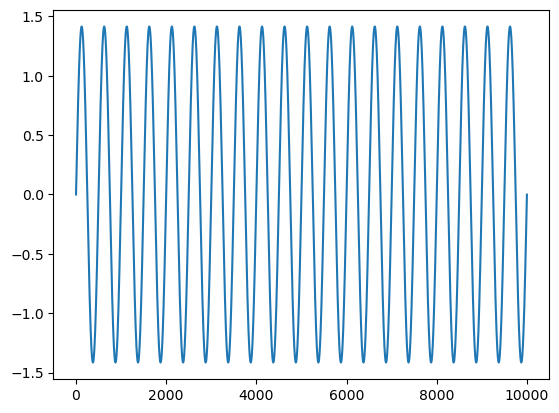

In [5]:
plt.plot(t, x[:, 0])
plt.show()

#### Run Current-Based Model model

In [44]:
## TORCH SETUP
seed = 1
np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

Using Device <cuda> for PyTorch computations...



In [45]:
Ne = 400
Ni = 100
# N = Ne + Ni

# input current for I and E neurons
Ie = 60
Ii = 60
current = np.array([Ie] * Ne + [Ii] * Ni).reshape(-1, 1)

# current = Ie
p = .01
gbar = 20
Q = 0

# x = np.zeros(shape=x.shape, dtype=float)
ml = MorrisLecarCurrent(supervisor=x, T=T, dt=dt, Ne=Ne, Ni=Ni, 
                        BIAS=current, gbar=gbar, Q=Q, ridge_coeff=1.0, 
                        device=device, p_sparsity=p)

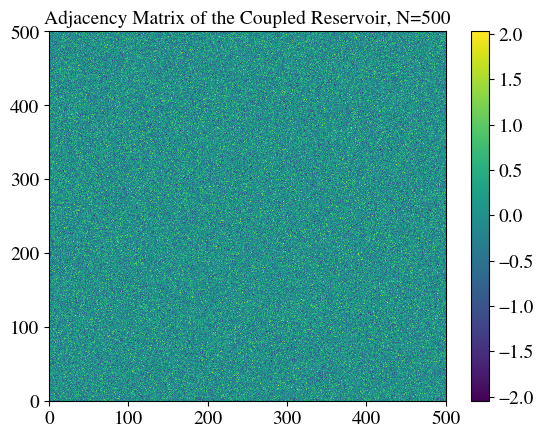

In [46]:
clr = plt.pcolormesh(ml.w.cpu().numpy(), cmap="viridis")
plt.colorbar(clr)
plt.title(f"Adjacency Matrix of the Coupled Reservoir, N={ml._N}")
# plt.savefig("img/weight_matrix.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [48]:
print("mean abs:", ml.w.abs().mean().item())
print("std:", ml.w.std().item())
print("mean:", ml.w.mean().item())
print("min", ml.w.min().item())
print("max:", ml.w.max().item())

mean abs: 0.35710275173187256
std: 0.4471626579761505
mean: -0.0007712726364843547
min -2.0483286380767822
max: 2.0257728099823


In [49]:
ml_copy = MorrisLecarCurrent(supervisor=x, T=T, dt=dt, Ne=Ne, Ni=Ni,
                            BIAS=current, gbar=gbar, Q=Q, ridge_coeff=1.0,
                            device=device, p_sparsity=p)
ml_copy.w = ml.w.clone()
ml_copy.v = ml.v.clone()
ml_copy.n = ml.n.clone()
ml_copy.s = ml.s.clone()

In [50]:
nt = t.shape[0]
v_trace = torch.zeros((nt, ml._N), device='cpu', dtype=torch.float32)
v_trace_copy = torch.zeros((nt, ml._N), device='cpu', dtype=torch.float32)

bias_start = T * 0.5
bias_end = T * 0.51
nt_start = int(bias_start / dt)
nt_end = int(bias_end / dt)

neuron_index = 5
ml_copy_bias = ml_copy._BIAS.clone()
ml_copy_bias_mod = ml_copy_bias.clone()
ml_copy_bias_mod[neuron_index, 0] = 0

In [51]:
for i in tqdm(range(nt)):
    ml.euler_step()
    v_trace[i] = ml.v.clone().squeeze().cpu()
    
    if i > nt_start and i < nt_end:
        ml_copy._BIAS = ml_copy_bias_mod
    else:
        ml_copy._BIAS = ml_copy_bias
    ml_copy.euler_step()
    v_trace_copy[i] = ml_copy.v.clone().squeeze()


100%|██████████| 100000/100000 [01:03<00:00, 1563.08it/s]


In [93]:
def plot_voltage_trace(voltage_trace_np:np.ndarray, v_trace_copy_np:np.ndarray, 
                       rands:np.ndarray, t, figsize:tuple=(12, 8), line_alpha:float=1.0, step:int=1,
                       save_dir:str="img", extension:str="png") -> tuple[np.ndarray, np.ndarray]:
    """
    Plot the initial dynamics in the reservoir.
    """
    fig = plt.figure(figsize=figsize, layout='tight')
    fig.suptitle("Chaotic reservoir dynamics during the pre-training phase")
    ax = fig.add_subplot(1, 1, 1)
    
    # Ax 0 -- Voltage trace
    rands_sorted = sorted(rands, reverse=False)
    for i, num in enumerate(rands_sorted):
        signal = voltage_trace_np[::step, num]
        minim = np.nanmin(signal)
        maxim = np.nanmax(signal)
        signal = (signal - minim) / (maxim - minim) + i + 0.5
        ax.plot(t[::step], signal, 'b-', lw=1, label="original", alpha=line_alpha)
        signal = v_trace_copy_np[::step, num]
        minim = np.nanmin(signal)
        maxim = np.nanmax(signal)
        signal = (signal - minim) / (maxim - minim) + i + 0.5
        ax.plot(t[::step], signal, 'r-', lw=1, label="spike removed", alpha=line_alpha)
    ax.grid(alpha=.5)
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Neuron index")
    xmargin = 100
    ax.set_xlim([-xmargin, t[-1]+xmargin])
    ax.set_yticks([i+1 for i in range(len(rands))], labels=[str(i) for i in rands_sorted], minor=False)
    ax.set_title("Voltage trace of randomly selected neurons")
    ax.legend(loc='upper right', labels=["original", "spike removed"])
    ax.axvline(x=bias_start, color='k', lw=1, ls='--')
    
    try:
        fig.savefig(os.path.join(save_dir, "initial_chaos_voltage_trace." + extension), dpi=300)
    except FileNotFoundError:
        print(f"Creating directory {save_dir}...")
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, "initial_chaos_voltage_trace." + extension), dpi=300)
    plt.show(fig)

In [94]:
mpl.rcParams["font.family"] = "Nimbus Roman"

mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.labelsize"] = 18
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["legend.title_fontsize"] = 12
# mpl.rcParams.keys()

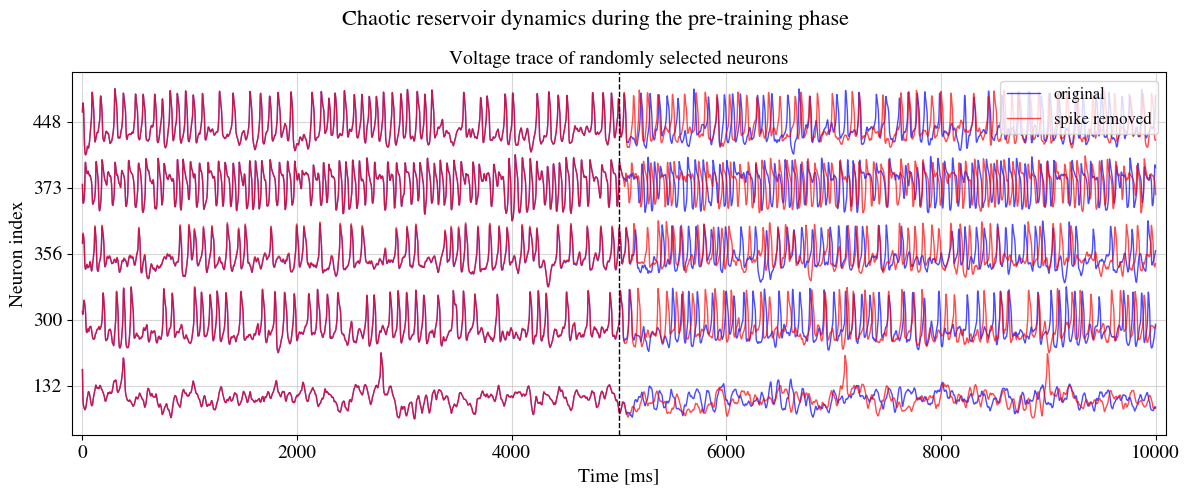

In [97]:
voltage_trace_np = v_trace.numpy()
np.random.seed(seed+21)
rands = np.random.randint(low=0, high=ml._N, size=5)

step = 10
shift = 7
plot_voltage_trace(
    voltage_trace_np, v_trace_copy.numpy(), rands, t, figsize=(12, 5), line_alpha=0.7,
    step=step, save_dir=save_dir, extension="png"
    )

In [ ]:
# Plot the raster plots for the original and modified voltage traces

spikes_original = [[] for _ in range(ml._N)]
spikes_modified = [[] for _ in range(ml._N)]

for i in tqdm(range(1, v_trace.size(0))):
    mask = torch.logical_and(v_trace[i, :] > ml._v_t, v_trace[i - 1, :] <= ml._v_t)
    if mask.any():
        # Get the indices of the spikes
        spikes = mask.nonzero(as_tuple=True)[0].cpu().numpy()
        for neuron in spikes:
            # Store the spike times for each neuron
            spikes_original[neuron].append(t[i])

    mask_copy = torch.logical_and(v_trace_copy[i, :] > ml._v_t, v_trace_copy[i - 1, :] <= ml._v_t)
    if mask_copy.any():
        # Get the indices of the spikes
        spikes = mask_copy.nonzero(as_tuple=True)[0].cpu().numpy()
        for neuron in spikes:
            # Store the spike times for each neuron
            spikes_modified[neuron].append(t[i])


100%|██████████| 99999/99999 [00:03<00:00, 33220.10it/s]


500

In [131]:
for i in tqdm(t[:nt_start]):
    for neuron in range(ml._N):
        if i in spikes_original[neuron] and i not in spikes_modified[neuron]:
            print(f"Neuron {neuron} spiked at time {t[i]} in original but not in modified")
        if i in spikes_modified[neuron] and i not in spikes_original[neuron]:
            print(f"Neuron {neuron} spiked at time {t[i]} in modified but not in original")

100%|██████████| 50000/50000 [00:32<00:00, 1532.99it/s]


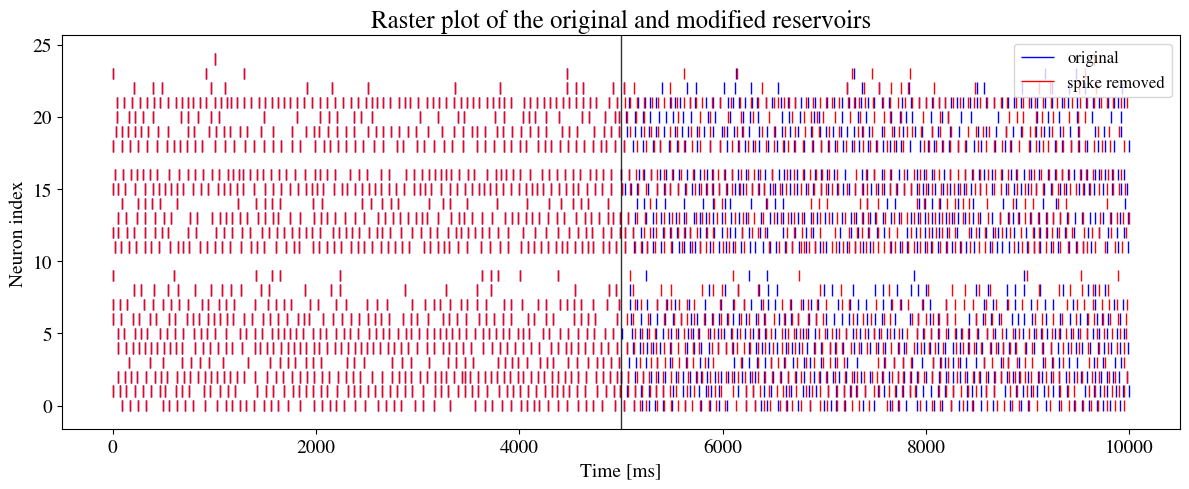

In [134]:
figure = plt.figure(figsize=(12, 5), layout='tight')
figure.add_subplot(1, 1, 1)
ax = figure.gca()
ax.set_title("Raster plot of the original and modified reservoirs", fontsize=18)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Neuron index")

# neurons = sorted(rands)
n_neurons = 25
neurons = np.arange(n_neurons)

for i, neuron in enumerate(neurons):
    # Plot the spikes for the original voltage trace
    ax.vlines(spikes_original[neuron], i - 0.4, i + 0.4, color='b', lw=1, label="original")
    # Plot the spikes for the modified voltage trace
    ax.vlines(spikes_modified[neuron], i - 0.4, i + 0.4, color='r', lw=1, label="spike removed")
step = 5
# ax.set_yticks([i for i in range(len(neurons))[::step]], labels=[str(i) for i in neurons[::step]], minor=True)
ax.legend(loc='upper right', labels=["original", "spike removed"])

ax.axvline(x=bias_start, color='k', lw=1, ls='-', alpha=.8)
figure.savefig(os.path.join(save_dir, "initial_chaos_raster_plot.png"), dpi=300)
plt.show(figure)